Лабораторная 1. Многослойный персептрон

Цель - создать архитектуру многослойного персептрона, классифицирующего грибы (mushroom_dataset).

Описание датасета - https://archive.ics.uci.edu/ml/datasets/Mushroom

2 скрытых слоя, функция активации сигмоида, градиентный спуск без оптимизаторов

Выходных нейрона 2, по количеству классов

Обучить нейронную сеть

Посчитать accuracy, precision, recall, F1-меру

Вывести ROC-кривую

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
mushroom = fetch_ucirepo(id=73)

# data (as pandas dataframes)
X = mushroom.data.features
y = mushroom.data.targets

In [3]:
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


In [4]:
y.head()

,poisonous
0,p
1,e
2,e
3,p
4,e


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in X.columns:
    label_encoders[column] = LabelEncoder()
    X[column] = label_encoders[column].fit_transform(X[column])


for column in y.columns:
    label_encoders[column] = LabelEncoder()
    y[column] = label_encoders[column].fit_transform(y[column])

In [6]:
X.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,5,2,4,1,6,1,0,1,4,0,...,2,7,7,0,2,1,4,2,3,5
1,5,2,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,3,2,1
2,0,2,8,1,3,1,0,0,5,0,...,2,7,7,0,2,1,4,3,2,3
3,5,3,8,1,6,1,0,1,5,0,...,2,7,7,0,2,1,4,2,3,5
4,5,2,3,0,5,1,1,0,4,1,...,2,7,7,0,2,1,0,3,0,1


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
import numpy as np

class MLP:
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        self.input_size = input_size
        self.hidden_size1 = hidden_size1
        self.hidden_size2 = hidden_size2
        self.output_size = output_size

        # self.weights_input_hidden1 = np.random.rand(self.input_size, self.hidden_size1)
        # self.bias_hidden1 = np.zeros((1, self.hidden_size1))

        # self.weights_hidden1_hidden2 = np.random.rand(self.hidden_size1, self.hidden_size2)
        # self.bias_hidden2 = np.zeros((1, self.hidden_size2))

        # self.weights_hidden2_output = np.random.rand(self.hidden_size2, self.output_size)
        # self.bias_output = np.zeros((1, self.output_size))

        self.weights_input_hidden1 = np.random.randn(self.input_size, self.hidden_size1) * np.sqrt(1.0 / self.input_size)
        self.weights_hidden1_hidden2 = np.random.randn(self.hidden_size1, self.hidden_size2) * np.sqrt(1.0 / self.hidden_size1)
        self.weights_hidden2_output = np.random.randn(self.hidden_size2, self.output_size) * np.sqrt(1.0 / self.hidden_size2)

        self.bias_hidden1 = np.zeros((1, self.hidden_size1))
        self.bias_hidden2 = np.zeros((1, self.hidden_size2))
        self.bias_output = np.zeros((1, self.output_size))

    def sigmoid(self, x):
      x_clipped = x.astype(float)
      return 1 / (1 + np.exp(-x_clipped))

    def sigmoid_derivative(self, x):
      return x * (1 - x)

    def forward(self, X):
        self.hidden_output1 = self.sigmoid(np.dot(X, self.weights_input_hidden1) + self.bias_hidden1)
        self.hidden_output2 = self.sigmoid(np.dot(self.hidden_output1, self.weights_hidden1_hidden2) + self.bias_hidden2)
        self.output = self.sigmoid(np.dot(self.hidden_output2, self.weights_hidden2_output) + self.bias_output)

        return self.output

    def backward(self, X, y, learning_rate):
        output_error = y - self.output
        output_delta = output_error * self.sigmoid_derivative(self.output)

        hidden2_error = output_delta.dot(self.weights_hidden2_output.T)
        hidden2_delta = hidden2_error * self.sigmoid_derivative(self.hidden_output2)

        hidden1_error = hidden2_delta.dot(self.weights_hidden1_hidden2.T)
        hidden1_delta = hidden1_error * self.sigmoid_derivative(self.hidden_output1)


        self.weights_hidden2_output += self.hidden_output2.T.dot(output_delta.astype('float64')) * learning_rate
        self.bias_output += np.sum(output_delta.astype('float64'), axis=0, keepdims=True) * learning_rate

        self.weights_hidden1_hidden2 += self.hidden_output1.T.dot(hidden2_delta.astype('float64')) * learning_rate
        self.bias_hidden2 += np.sum(hidden2_delta.astype('float64'), axis=0, keepdims=True) * learning_rate

        self.weights_input_hidden1 += X.T.dot(hidden1_delta.astype('float64')) * learning_rate
        self.bias_hidden1 += np.sum(hidden1_delta.astype('float64'), axis=0, keepdims=True) * learning_rate


    def train(self, X, y, epochs, learning_rate):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, learning_rate)

            if epoch % 100 == 0:
                loss = np.mean(np.square(y - output))
                print(f"Epoch {epoch}, Loss: {loss}")

    def predict(self, X):
        return np.round(self.forward(X))

In [9]:
input_size = X_train.shape[1]
hidden_size1 = 32
hidden_size2 = 16
output_size = 1
mlp = MLP(input_size, hidden_size1, hidden_size2, output_size)

X_train = X_train.astype('float64')
y_train = y_train.astype('float64')
epochs = 1001
learning_rate = 0.001

In [10]:
mlp.train(X_train.values, y_train.values, epochs, learning_rate)

Epoch 0, Loss: 0.28834012844813695
Epoch 100, Loss: 0.10010260374756698
Epoch 200, Loss: 0.05389384964974857
Epoch 300, Loss: 0.07661415226115012
Epoch 400, Loss: 0.028259767496569
Epoch 500, Loss: 0.010837006845672728
Epoch 600, Loss: 0.038092262887511094
Epoch 700, Loss: 0.003997070909274439
Epoch 800, Loss: 0.00218801730046089
Epoch 900, Loss: 0.0013478133100958262
Epoch 1000, Loss: 0.0009342512534831795


In [11]:
y_pred = mlp.predict(X_test.values)

In [12]:
y_pred

array([[0.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]])

In [13]:
y_test = np.array(y_test, dtype=float)
y_test

array([[0.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]])

In [14]:
accuracy = sum(y_test == y_pred) / len(y_test)

In [15]:
true_positives = sum((y_test == 1) & (y_pred == 1))
predicted_positives = sum(y_pred == 1) #TP+FP
precision = true_positives / predicted_positives if predicted_positives != 0 else 0

In [16]:
actual_positives = sum(y_test == 1) #TP+FN
recall = true_positives / actual_positives if actual_positives != 0 else 0

In [17]:
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

In [18]:
n = len(y_test)
n_positive = sum(y_test == 1)
n_negative = n - n_positive

thresholds = sorted(set(tuple(pred) for pred in y_pred), reverse=True)

fpr = [0]
tpr = [0]
for threshold in thresholds:
    y_pred_binary = y_pred >= threshold
    true_positive = sum((y_test == 1) & (y_pred_binary == 1))
    false_positive = sum((y_test == 0) & (y_pred_binary == 1))
    tpr.append(true_positive / n_positive)
    fpr.append(false_positive / n_negative)
fpr.append(1)
tpr.append(1)



In [19]:
auc_score = 0
for i in range(len(fpr) - 1):
    auc_score += (fpr[i + 1] - fpr[i]) * (tpr[i + 1] + tpr[i]) / 2

In [20]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC:", auc_score)

Accuracy: [1.]
Precision: [1.]
Recall: [1.]
F1-score: [1.]
AUC: [1.]


In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

/tmp/ipython-input-2814092494.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_score)


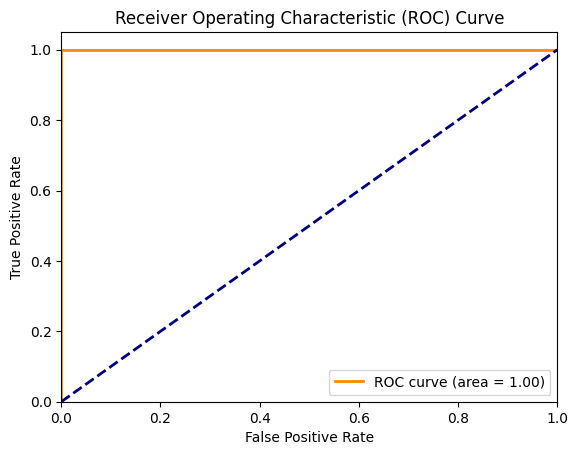

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
